# Lab 4: Feature Points

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

imagesDir = '../images' # Change this, according to your images' directory path

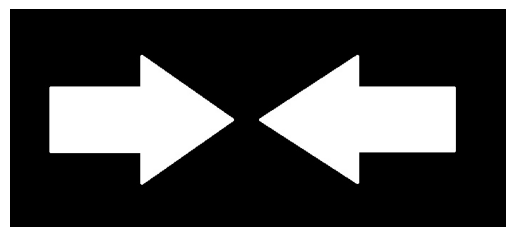

In [2]:
# Read image 
filename = 'corners_01.jpg'
img = cv2.imread(os.path.join(imagesDir, filename))

# Show image
plt.imshow(img)
_ = plt.axis("off")

# Copy the image to be able to use it later without having to read it again
og_img = img.copy() 

### 1. Corner Detection

[Harris Corner Detector](https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#gac1fc3598018010880e370e2f709b4345)

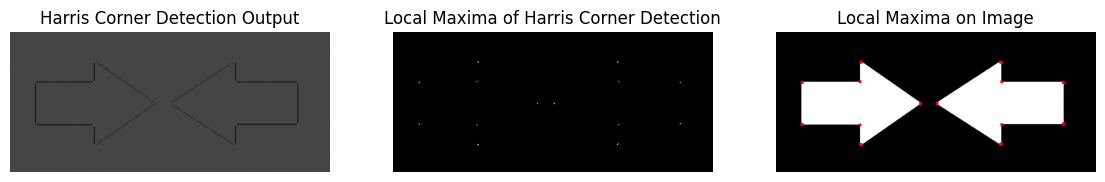

In [3]:
img = og_img.copy()

# Convert image into grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Change dtype to avoid overflow/underflow
gray = np.float32(gray)

# Apply Harris Corner Detector
dst = cv2.cornerHarris(gray, blockSize = 2, ksize = 3, k = 0.04)

# Define threshold for an optimal value, it may vary depending on the image
thr = 0.01

# Apply threshold to obtain local maxima
thresh = np.where(dst < thr * dst.max(), 0, 255)

# Dilation operation to make corners bigger / more visible
dilated_dst = cv2.dilate(dst, None, iterations=2)

# Set pixels corresponding to corners (selected using the previous threshold) to red
img[dilated_dst > thr * dst.max()] = [0, 0, 255]

# Normalize output of Harris Corner Detection for visualization purposes
dst = (dst - dst.min()) / (dst.max() - dst.min()) * 255

# Show results
f, axarr = plt.subplots(1, 3, figsize=(14, 4))
axarr[0].imshow(dst, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("Harris Corner Detection Output")
axarr[0].axis("off")

axarr[1].imshow(thresh, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Local Maxima of Harris Corner Detection")
axarr[1].axis("off")

axarr[2].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[2].set_title("Local Maxima on Image")
_ = axarr[2].axis("off")

In the direct output of the Harris Corner Detection algorithm, notice that:
 * Edges are represented in black, corresponding to negative values in the direct output of the algorithm (which were set to zero with the normalization);
 * Corners are represented in white, since they represent the largest positive values / local maxima (which were set to 255 with the normalization);
 * Flat areas are represented in gray, since they correspond to values close to zero in the output of the algorithm

[Shi-Tomasi Corner Detector](https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#ga1d6bb77486c8f92d79c8793ad995d541)

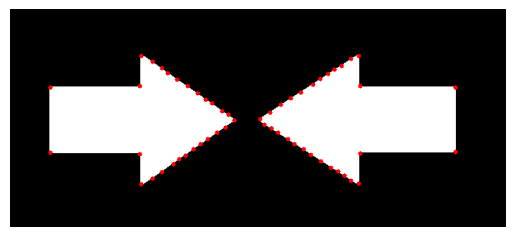

In [4]:
img2 = og_img.copy()
gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Apply Shi-Tomasi Corner Detector
corners = cv2.goodFeaturesToTrack(gray, maxCorners = 200, qualityLevel = 0.01, minDistance = 10, blockSize=2, k=0.04, useHarrisDetector=False)
corners = np.intp(corners)

# Draw corners on image
for i in corners:
    x, y = i.ravel()
    cv2.circle(img2, (x, y), 3, (0, 0, 255), -1)

# Show image
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

**Exercise 1.1**: Implement the [FAST Corner Detector](https://docs.opencv.org/4.x/df/d0c/tutorial_py_fast.html) to detect corners in images. Disable non maximum suppression and compare the results.

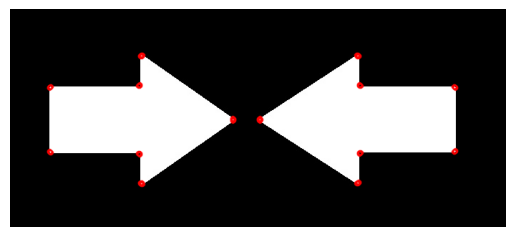

In [5]:
img3 = og_img.copy()
gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

fast = cv2.FastFeatureDetector_create()
fast.setNonmaxSuppression(0)

kp = fast.detect(gray, None)

final_img = cv2.drawKeypoints(gray, kp, None, color=(0,0,255))

plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

**Exercise 1.2**: Verify the impact of resizing the image before applying each of the corner detectors by:
 * Downsizing the image to 1/4 of its original size
 * Upsizing the image to twice its original size

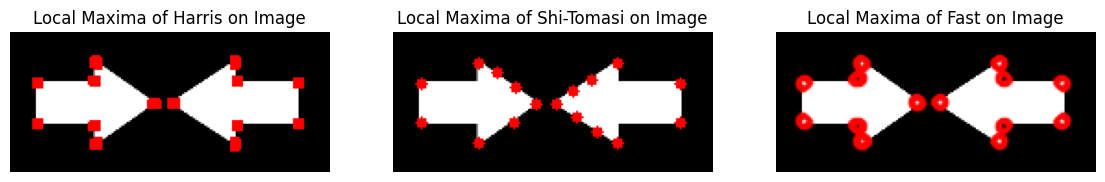

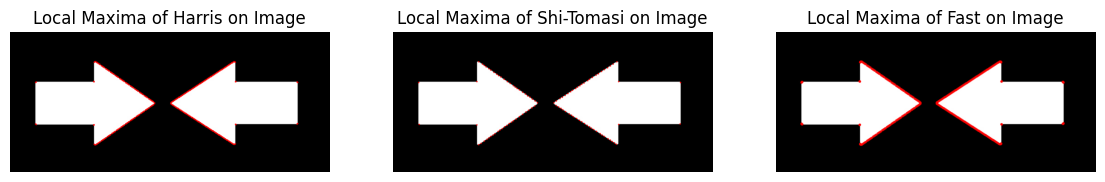

In [6]:
def apply_corner_detectors(img, gray):
    fast_gray = gray.copy()
    gray = np.float32(gray)

    # Apply Harris Corner Detector
    dst = cv2.cornerHarris(gray, blockSize = 2, ksize = 3, k = 0.04)

    # Define threshold for an optimal value, it may vary depending on the image
    thr = 0.01

    # Apply threshold to obtain local maxima
    thresh = np.where(dst < thr * dst.max(), 0, 255)

    # Dilation operation to make corners bigger / more visible
    dilated_dst = cv2.dilate(dst, None, iterations=2)
    
    # Set pixels corresponding to corners (selected using the previous threshold) to red
    harris_img = img.copy()
    harris_img[dilated_dst > thr * dst.max()] = [0, 0, 255]

    # Normalize output of Harris Corner Detection for visualization purposes
    dst = (dst - dst.min()) / (dst.max() - dst.min()) * 255

    # Shi-Tomasi
    shi_tomasi = img.copy()
    corners = cv2.goodFeaturesToTrack(gray, maxCorners = 200, qualityLevel = 0.01, minDistance = 10, blockSize=2, k=0.04, useHarrisDetector=False)
    corners = np.intp(corners)

    # Draw corners on image
    for i in corners:
        x, y = i.ravel()
        cv2.circle(shi_tomasi, (x, y), 3, (0, 0, 255), -1)

    # FAST Corner 
    fast = cv2.FastFeatureDetector_create()
    fast.setNonmaxSuppression(0)

    kp = fast.detect(fast_gray, None)

    fast_dectection = cv2.drawKeypoints(fast_gray, kp, None, color=(0,0,255))

    # Show results
    f, axarr = plt.subplots(1, 3, figsize=(14, 4))
    

    axarr[0].imshow(cv2.cvtColor(harris_img, cv2.COLOR_BGR2RGB))
    axarr[0].set_title("Local Maxima of Harris on Image")
    _ = axarr[0].axis("off")

    axarr[1].imshow(cv2.cvtColor(shi_tomasi, cv2.COLOR_BGR2RGB))
    axarr[1].set_title("Local Maxima of Shi-Tomasi on Image")
    _ = axarr[1].axis("off")

    axarr[2].imshow(cv2.cvtColor(fast_dectection, cv2.COLOR_BGR2RGB))
    axarr[2].set_title("Local Maxima of Fast on Image")
    _ = axarr[2].axis("off")
    

img4 = og_img.copy()

downscaled = cv2.resize(img4.copy(), None, fx=0.25, fy=0.25)
downscaled_gray = cv2.cvtColor(downscaled, cv2.COLOR_BGR2GRAY)

apply_corner_detectors(downscaled, downscaled_gray)

upscaled = cv2.resize(img4.copy(), None, fx=2, fy=2)
upscaled_gray = cv2.cvtColor(upscaled, cv2.COLOR_BGR2GRAY)

apply_corner_detectors(upscaled, upscaled_gray)

### 2. Blob Detection

[SIFT Blob Detector](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

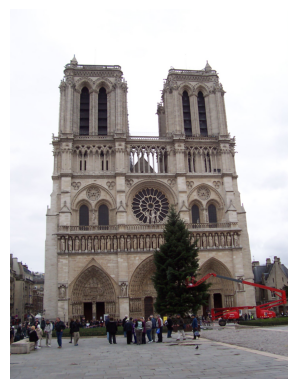

In [7]:
new_img = cv2.imread(os.path.join(imagesDir, 'match_NotreDame_1.jpg'))
gray = cv2.cvtColor(new_img, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

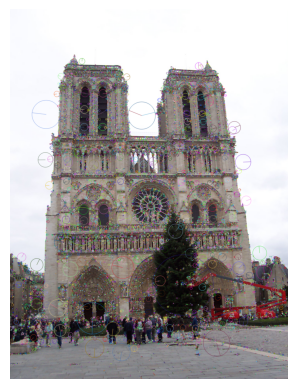

In [8]:
# Initiate SIFT detector
sift = cv2.SIFT_create()

# Find the keypoints
kp = sift.detect(gray, None)

# Draw the keypoints (with size and orientation)
sift_img = cv2.drawKeypoints(new_img, kp, None, (-1, -1, -1), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Show image
plt.imshow(cv2.cvtColor(sift_img, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

**Exercise 2.1**: Implement keypoint detection with the [Orb Blob Detector](https://docs.opencv.org/4.x/d1/d89/tutorial_py_orb.html) and compare the results with those obtained using SIFT.

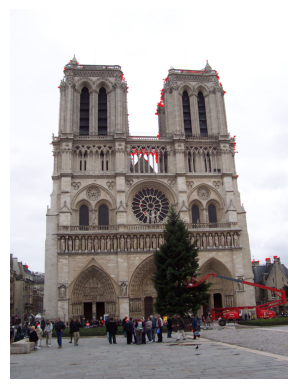

In [9]:
orb = cv2.ORB_create()

kp = orb.detect(new_img,None)

kp, des = orb.compute(new_img, kp)

orb_blob_img = cv2.drawKeypoints(new_img, kp, None, color=(0,0,255))

plt.imshow(cv2.cvtColor(orb_blob_img, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

### 3. Matching 

Check tutorial [here](https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html).

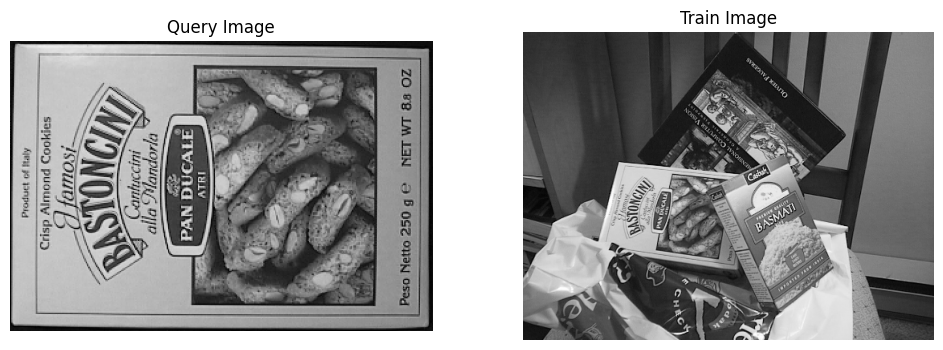

In [10]:
# Read images
query = cv2.imread(os.path.join(imagesDir, 'match_box01a_1.png'), cv2.IMREAD_GRAYSCALE) # queryImage
train = cv2.imread(os.path.join(imagesDir, 'match_box01a_2.png'), cv2.IMREAD_GRAYSCALE) # trainImage

# Show images
f, axarr = plt.subplots(1, 2, figsize=(12, 4))
axarr[0].imshow(query, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("Query Image")
axarr[0].axis("off")

axarr[1].imshow(train, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Train Image")
_ = axarr[1].axis("off")

Match keypoints in images using:
 * Orb Detector for keypoint detection
 * Brute Force matcher with Hamming similarity (ideal for Orb Detector)

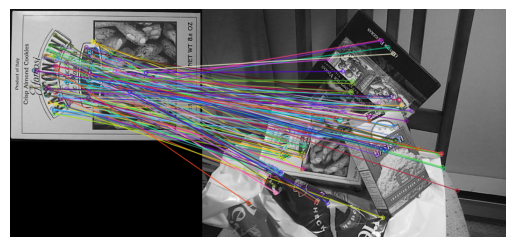

In [11]:
# Initiate ORB detector
orb = cv2.ORB_create()

# Find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(query, None)
kp2, des2 = orb.detectAndCompute(train, None)

# Create a Brute Force Matcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match descriptors
matches = bf.match(des1, des2)

# Sort them in the order of their distance
matches = sorted(matches, key = lambda x:x.distance)

# Draw matches
match_output = cv2.drawMatches(query, kp1, train, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Show matches
plt.imshow(cv2.cvtColor(match_output, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

**Exercise 3.1**: Replace the Orb Detector by SIFT for keypoint detection and verify the results.

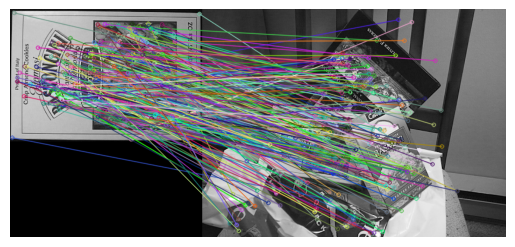

In [12]:
sift = cv2.SIFT_create()

# Find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(query, None)
kp2, des2 = sift.detectAndCompute(train, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Match descriptors
matches = bf.match(des1, des2)

# Sort them in the order of their distance
matches = sorted(matches, key = lambda x:x.distance)

# Draw matches
match_output = cv2.drawMatches(query, kp1, train, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Show matches
plt.imshow(cv2.cvtColor(match_output, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

**Exercise 3.2**: Save the top-2 best matches for each keypoint and apply Lowe's ratio test to remove outliers.

**Tips**: 
* You can find the top-k best matches for each keypoint by replacing ```match()``` with ```knnMatch()```. 
* You can draw all k matches using ```drawMatchesKnn()``` instead of ```drawMatches()```. 
* Lowe's ratio test analyses the two best matches. If the two best matches have similar distances, then both matches are removed. The best match is only saved if its distance is sufficiently smaller than the distance of the second-best match.

(np.float64(-0.5), np.float64(835.5), np.float64(383.5), np.float64(-0.5))

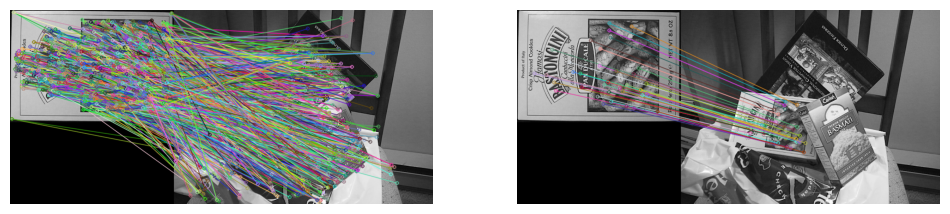

In [13]:
sift = cv2.SIFT_create()

# Find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(query, None)
kp2, des2 = sift.detectAndCompute(train, None)

bf = cv2.BFMatcher(cv2.NORM_L2)

# Match descriptors
matches = bf.knnMatch(des1, des2, k=2)

# Draw matches
match_output = cv2.drawMatchesKnn(query, kp1, train, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

matches_with_ratio = []
for m, n in matches:
    if m.distance < 0.5 * n.distance:  # Lowe's ratio test
        matches_with_ratio.append(m)
matches_with_ratio_output = cv2.drawMatches(query, kp1, train, kp2, matches_with_ratio, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Show matches
_, axarr = plt.subplots(1,2,figsize=(12,4))
axarr[0].imshow(cv2.cvtColor(match_output, cv2.COLOR_BGR2RGB))
axarr[0].axis("off")


axarr[1].imshow(cv2.cvtColor(matches_with_ratio_output, cv2.COLOR_BGR2RGB))
axarr[1].axis("off")

**Exercise 3.3**: Replace the Brute Force algorithm by FLANN for keypoint matching.

(np.float64(-0.5), np.float64(835.5), np.float64(383.5), np.float64(-0.5))

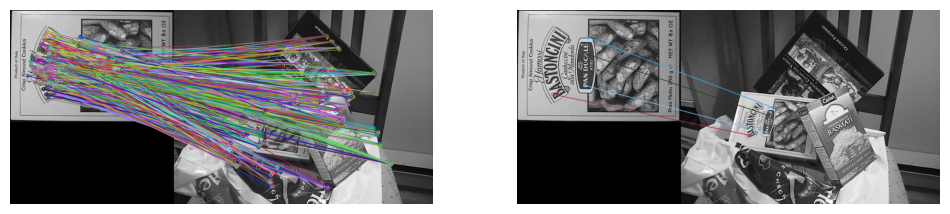

In [23]:
# Must use ORB
orb = cv2.ORB_create()

# Find the keypoints and descriptors with SIFT
kp1, des1 = orb.detectAndCompute(query, None)
kp2, des2 = orb.detectAndCompute(train, None)

# Not brute force using FLANN
FLANN_INDEX_LSH = 6
index_params = dict(algorithm=FLANN_INDEX_LSH, table_number=8, key_size=12, multi_probe_level=1)
search_params = dict(checks=100)

# Initialize FLANN-based matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1, des2, k=2)

# Draw matches
match_output = cv2.drawMatchesKnn(query, kp1, train, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

matches_with_ratio = []

for m, n in matches:
    if m.distance < 0.5 * n.distance:  # Lowe's ratio test
        matches_with_ratio.append(m)
matches_with_ratio_output = cv2.drawMatches(query, kp1, train, kp2, matches_with_ratio, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Show matches
_, axarr = plt.subplots(1,2,figsize=(12,4))
axarr[0].imshow(cv2.cvtColor(match_output, cv2.COLOR_BGR2RGB))
axarr[0].axis("off")


axarr[1].imshow(cv2.cvtColor(matches_with_ratio_output, cv2.COLOR_BGR2RGB))
axarr[1].axis("off")

**Exercise 3.4**: Find Wally! Given an image of Wally's profile and a puzzle where Wally is hidden, apply keypoint detection and matching algorithms to find Wally.

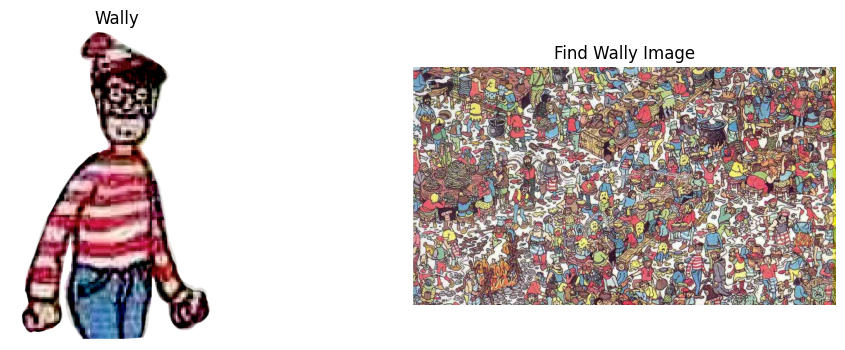

In [15]:
img_wallys_face = cv2.imread("../images/wally.png")
img_find_wally = cv2.imread("../images/find_wally.jpg")

# Show images
f, axarr = plt.subplots(1, 2, figsize=(12, 4))
axarr[0].imshow(cv2.cvtColor(img_wallys_face, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Wally")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img_find_wally, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Find Wally Image")
_ = axarr[1].axis("off")

(np.float64(-0.5), np.float64(2295.5), np.float64(1079.5), np.float64(-0.5))

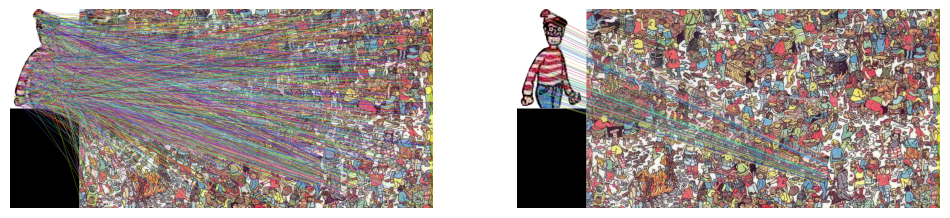

In [16]:
sift = cv2.SIFT_create()

# Find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img_wallys_face, None)
kp2, des2 = sift.detectAndCompute(img_find_wally, None)

bf = cv2.BFMatcher(cv2.NORM_L2)

# Match descriptors
matches = bf.knnMatch(des1, des2, k=2)

# Draw matches
match_output = cv2.drawMatchesKnn(img_wallys_face, kp1, img_find_wally, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

matches_with_ratio = []
for m, n in matches:
    if m.distance < 0.5 * n.distance:  # Lowe's ratio test
        matches_with_ratio.append(m)
matches_with_ratio_output = cv2.drawMatches(img_wallys_face, kp1, img_find_wally, kp2, matches_with_ratio, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Show matches
_, axarr = plt.subplots(1,2,figsize=(12,4))
axarr[0].imshow(cv2.cvtColor(match_output, cv2.COLOR_BGR2RGB))
axarr[0].axis("off")


axarr[1].imshow(cv2.cvtColor(matches_with_ratio_output, cv2.COLOR_BGR2RGB))
axarr[1].axis("off")